In [1]:
from xaikd import datasets, models, utils, constants, attributors

from torch.utils.data import random_split, DataLoader

from torchvision.datasets import CIFAR100
from torchmetrics.classification import BinaryAUROC

from torch.nn import functional as F

import pandas as pd
import torch
import numpy as np 
import numpy.typing as npt

from tqdm.notebook import tqdm
from torch import nn

from datetime import datetime

from matplotlib import pyplot as plt

In [2]:
pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)["coarse_label_name"].unique()

array(['aquatic_mammals', 'food_containers', 'small_mammals',
       'large_natural_outdoor_scenes', 'large_carnivores', 'vehicles_1',
       'people', 'flowers', 'medium_mammals', 'reptiles',
       'large_omnivores_and_herbivores', 'fruit_and_vegetables', 'trees',
       'household_furniture', 'vehicles_2', 'fish',
       'household_electrical_devices', 'large_man_made_outdoor_things',
       'insects', 'non_insect_invertebrates'], dtype=object)

In [3]:
DEVICE = utils.get_device()

DEVICE

DATA_SIZE = 0.1


SELECTED_GROUP = "class2"

In [4]:
dataset = datasets.construct("cifar100")

In [5]:
def get_fine_labels(name):

    if "class" in name:
        label = int(name.replace("class", ""))
        return [label]
    df = pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)
    return sorted(df[df.coarse_label_name == name].fine_label.values)
SELECTED_CLASSES = get_fine_labels(SELECTED_GROUP)
SELECTED_CLASSES

[2]

In [6]:
NOT_SELECTED_CLASSES = sorted(set(np.arange(100)).difference(SELECTED_CLASSES))

In [7]:
NOT_SELECTED_CLASSES

[0,
 1,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99]

In [8]:
def target_transform(label):
    if label in SELECTED_CLASSES:
        return 1
    else:
        return 0

In [9]:
trng = torch.Generator()
trng.manual_seed(1)

transform = datasets.construct("cifar100").input_transformation
ds_train = CIFAR100(root="../../datasets", download=False, train=True, transform=transform, target_transform=target_transform)
ds_train, _ = random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])

ds_val = CIFAR100(root="../../datasets", download=False, train=False, transform=transform,  target_transform=target_transform)

dl_train = DataLoader(ds_train, num_workers=12, shuffle=False, batch_size=128)
dl_val = DataLoader(ds_val, num_workers=12, shuffle=False,  batch_size=128)

In [10]:
def ano():
    for label, dl in [
        ("train", dl_train),
        ("val", dl_val),
    ]:
        arr_values = []
        for _, y in tqdm(dl):
            arr_values.extend(y.tolist())
        print(f"[subset={label}] p(y=1)={np.mean(arr_values):.4f}")
ano()

  0%|          | 0/40 [00:00<?, ?it/s]

[subset=train] p(y=1)=0.0118


  0%|          | 0/79 [00:00<?, ?it/s]

[subset=val] p(y=1)=0.0100


In [11]:
class LastLayerBinary(nn.Module):
    def __init__(self, fc):
        super().__init__()
        self.fc = fc

    def forward(self, x):
        logits = self.fc(x)
        lse_pos = torch.logsumexp(logits[:, SELECTED_CLASSES], dim=1)
        lse_neg = torch.logsumexp(logits[:, NOT_SELECTED_CLASSES], dim=1)
        return lse_pos - lse_neg
        
        
        # max_logit_selected = logits[:, SELECTED_CLASSES].max(dim=1).values
        # max_logit_notselected = logits[:, NOT_SELECTED_CLASSES].max(dim=1).values

        # assert len(max_logit_selected.shape) == 1

        # return max_logit_selected - 0* max_logit_notselected
        
    
def construct_model():
    model = models.get_trained_model("cifar100-resnet18-v1")

    model.fc = LastLayerBinary(model.fc)
    model.eval()
    model.to(DEVICE)
    
    return model

def sanity_check():
    
    model  = construct_model()

    output = model(torch.randn((5, 3, 32, 32)).to(DEVICE))
    assert output.shape == (5,)
    print("[Sanity check passed]: Model is callable")
    
sanity_check()

[Sanity check passed]: Model is callable


In [12]:
model = construct_model()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [13]:
def compute_performance(model, verbose=False):
    dl =  dl_val
    metric = BinaryAUROC(thresholds=20)
    model.to(DEVICE)

    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        
        metric.update(logit, y)

    metric = float(metric.compute())
    metric = np.max([metric, 1-metric])
    return metric
    
ref_performance = compute_performance(model, verbose=True)    
ref_performance

  0%|          | 0/79 [00:00<?, ?it/s]

0.9127237200737

  0%|          | 0/40 [00:00<?, ?it/s]

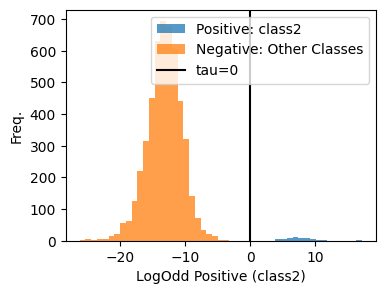

In [14]:
def compute_logit_distribution(model, verbose=False):
    dl =  dl_train

    arr_logits = []
    arr_y = []
    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        arr_y.extend(y.detach().numpy().tolist())
        arr_logits.extend(logit.detach().numpy().tolist())

    arr_logits = np.array(arr_logits) 
    arr_y = np.array(arr_y)
    plt.figure(figsize=(4, 3))
    vmin, vmax = np.min(arr_logits), np.max(arr_logits)
    bins = np.linspace(vmin, vmax, 50)
    
    plt.hist(
        arr_logits[arr_y == 1],
        bins=bins,
        label=f"Positive: {SELECTED_GROUP}",
        alpha=0.75
    )
    plt.hist(
        arr_logits[arr_y == 0],
        bins=bins,
        label=f"Negative: Other Classes",
        alpha=0.75
    )
    tau = 0
    plt.axvline(tau, label=f"tau={tau}", color="black")
    plt.ylabel("Freq.")
    plt.xlabel(f"LogOdd Positive ({SELECTED_GROUP})")
    plt.legend()
    
compute_logit_distribution(model, verbose=True)    

# Extract Activation

In [15]:
class VoidAttributor:

    def __enter__(self, **kwargs):
        pass

    def __exit__(self, type, value, tb):
        pass

def compute_logodd_winning(logits):

    return torch.sign(logits).detach() * logits

def compute_logits(logits):

    return logits

class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__
        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits


class LogOddSquared(OutputQuantity):
    def __call__(self, logits, targets):
        return (torch.sign(logits).detach() * logits).pow(2)

        
class LogOddPositiveClass(OutputQuantity):
    def __call__(self, logits, targets):
        return logits

        
class LogOddIfPositiveClass(OutputQuantity):
    def __call__(self, logits, targets):
        return (logits >= 0)*logits


class LogOddIfNegativeClass(OutputQuantity):
    def __call__(self, logits, targets):
        return (logits < 0)*logits


class LogOddTargetClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(2*targets-1) * logits
        

class BinaryCrossEntropyWinning(OutputQuantity):
    def __call__(self, logits, targets):
        winning_target = torch.sign(logits).detach()
        return - F.binary_cross_entropy_with_logits(logits, winning_target)



In [16]:
OUTPUT_QUANTITY = LogOddWinningClass()

def extract_activation_context_for_task(
    model: nn.Module,
    layer: str,
    selecting_only_samples_with_positive_logit,
    data_loader=dl_train,
    output_quantity=OUTPUT_QUANTITY,
    seed=1,
    device=DEVICE,
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):

    arr_logodds = []
    arr_act = []
    arr_ctx = []

    rng = np.random.default_rng(seed=1)

    try:
        
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        
        for batch in tqdm(data_loader, desc=f"[layer={layer}] extract actctx (group={SELECTED_GROUP} (positive_logit={selecting_only_samples_with_positive_logit} wrt {output_quantity})"):
            x, y = batch
            x = x.to(device)


            logits = model(x)
            
            quantities = output_quantity(logits, y)
            
            (quantities).sum().backward()
            act = utils.interceptor.get_output(module)

            assert act.grad is not None
            ctx = act.grad
            
            output_dimensions = act.shape[1:]

            assert ctx.shape == act.shape
            
            act = act.detach().cpu().numpy()
            ctx = ctx.detach().cpu().numpy()

            
            if selecting_only_samples_with_positive_logit:
                selected = (logits > 0).detach().cpu().numpy()
                
                if selected.sum() == 0:
                    continue

                act = act[selected,:, :, :]
                ctx = ctx[selected,:, :, :]
        

            selected_act, selected_ctx = utils.subsample_tensors(
                act,
                ctx,
                num_locations=number_of_selected_spatial_locations,
                rng=rng,
            )
            

            arr_act.append(selected_act)
            arr_ctx.append(selected_ctx)

    finally:
        hook.remove()
        model.fc.task_id = None

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
 
    return arr_act, arr_ctx


def ano():

    arr_act, arr_ctx = extract_activation_context_for_task(
        model, 
        "layer3",
        selecting_only_samples_with_positive_logit=False,
        data_loader=dl_train,
    )
    print(arr_act.shape)

    arr_act, arr_ctx = extract_activation_context_for_task(
        model, 
        "layer3",
        selecting_only_samples_with_positive_logit=True,
        data_loader=dl_train,
    )
    print(arr_act.shape)

    print(f"Sanity check: passed!")
ano()

[layer=layer3] extract actctx (group=class2 (positive_logit=False wrt LogOddWinningClass):   0%|          | 0/…

layer3: output-dims=torch.Size([256, 8, 8])
(100000, 256)


[layer=layer3] extract actctx (group=class2 (positive_logit=True wrt LogOddWinningClass):   0%|          | 0/4…

layer3: output-dims=torch.Size([256, 8, 8])
(1180, 256)
Sanity check: passed!


# Construct Basis

In [17]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, sort_func(eigvals)


class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        cov = arr_act.T @ arr_act / N
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        
        cov = arr_ctx.T @ arr_ctx / N
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
        
class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, _ = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCAPosDef(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCAPosDefNormUpToKEigvals(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)

        self.eigvals_pca = pca.eigvals
        self.eigvals_gradpca = gradpca.eigvals
        
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx
        
    def get_Uk(self, k: int):
        
        arr_act = self.arr_act / ( np.sum(self.eigvals_pca[:k] ** 2) ** 0.5)
        arr_ctx = self.arr_ctx / ( np.sum(self.eigvals_gradpca[:k] ** 2) ** 0.5)

        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        U, _ = _solve_eigvecs(cov)
        
        return U[:, :k]


class PRCAPosDefNormWithLargestEigval(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.max(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.max(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAPosDefNormWithFrobenious(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / np.linalg.norm(pca.cov)
        arr_ctx = arr_ctx / np.linalg.norm(gradpca.cov)

        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCASigmaASigmaAC(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCASigmaCSigmaAC(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


# Estimate Performance

In [18]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_aurocs_at_k(
    model, layer, 
    arr_ks,
    selecting_only_samples_with_positive_logit,
    arr_basis_names=[
        PCA
    ],
    
):
    arr_act, arr_ctx = extract_activation_context_for_task(
        model=model, 
        layer=layer, 
        selecting_only_samples_with_positive_logit=selecting_only_samples_with_positive_logit
    )
    
    module = getattr(model, layer)

    arr_dfs = []
    for basis_class in arr_basis_names:
        arr_stat_rows = []

        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
        )
        basis_name = basis_class.__name__

        for k in tqdm(
            arr_ks,
            desc=f"[{basis_name:>20s}] Estimating Performance"
        ):
        
            if ("-k" in basis_name) and not f"{k}" == basis_name.split("k")[1]:
                continue

            Uk = basis.get_Uk(k=k)

            row = dict(
                data_group=SELECTED_GROUP,
                output=OUTPUT_QUANTITY,
                positive_logits=selecting_only_samples_with_positive_logit,
                layer=layer,
                k=k,
                basis_name=basis_name,
            )

            Uk = torch.from_numpy(Uk).float().to(DEVICE)

            arr_hooks = []
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                arr_hooks.append(hook)

                if hasattr(basis, "pre_filters") and len(basis.pre_filters) > 0:
                    print("we pre filter")
                    for filter_layer, filter_Uk in basis.pre_filters:
                        
                        layer_module = getattr(model, filter_layer)
                        hook = layer_module.register_forward_hook(
                            construct_fh(
                                torch.from_numpy(filter_Uk).float().to(DEVICE)
                            )
                        )
                        arr_hooks.append(hook)
                
                for label, dl in [
                    # ("train", dl_train),
                    ("val", dl_val)
                ]:
                    row[f"{label}_auroc"] = compute_performance(model)
                
            finally:
                for hook in arr_hooks:
                    hook.remove()

            if hasattr(basis, "is_slow"):
                print(f"k={k}", row)
            arr_stat_rows.append(row)
            
     
        df = pd.DataFrame(arr_stat_rows)

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", f"val_auroc"], ascending=[True, False])
    
    return df

compute_task_aurocs_at_k(
    model, layer="layer4", 
    selecting_only_samples_with_positive_logit=False,
    arr_basis_names=[
        # PCA,
        # GradPCA,     
        # # PRCA,
        # PRCASortAbs,
        PRCAPosDef,
        # PRCAPosDefNormWithFrobenious,
        PRCAPosDefNormUpToKEigvals
        # PRCASigmaCSigmaAC,
    ],
    arr_ks=[1, 5, 20],
)

[layer=layer4] extract actctx (group=class2 (positive_logit=False wrt LogOddWinningClass):   0%|          | 0/…

layer4: output-dims=torch.Size([512, 4, 4])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCAPosDefNormUpToKEigvals] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,data_group,output,positive_logits,layer,k,basis_name,val_auroc
0,class2,LogOddWinningClass,False,layer4,1,PRCAPosDefNormUpToKEigvals,0.976961
0,class2,LogOddWinningClass,False,layer4,1,PRCAPosDef,0.818912
1,class2,LogOddWinningClass,False,layer4,5,PRCAPosDefNormUpToKEigvals,0.977814
1,class2,LogOddWinningClass,False,layer4,5,PRCAPosDef,0.977280
2,class2,LogOddWinningClass,False,layer4,20,PRCAPosDef,0.969682
2,class2,LogOddWinningClass,False,layer4,20,PRCAPosDefNormUpToKEigvals,0.960188


In [19]:
compute_task_aurocs_at_k(
    model, layer="layer2", 
    selecting_only_samples_with_positive_logit=False,
    arr_basis_names=[
        PRCAPosDef,
        PRCAPosDefNormWithFrobenious,
        PRCAPosDefNormUpToKEigvals
    ],
    arr_ks=[1, 10, 20],
)

[layer=layer2] extract actctx (group=class2 (positive_logit=False wrt LogOddWinningClass):   0%|          | 0/…

layer2: output-dims=torch.Size([128, 16, 16])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCAPosDefNormWithFrobenious] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCAPosDefNormUpToKEigvals] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,data_group,output,positive_logits,layer,k,basis_name,val_auroc
0,class2,LogOddWinningClass,False,layer2,1,PRCAPosDef,0.500000
0,class2,LogOddWinningClass,False,layer2,1,PRCAPosDefNormWithFrobenious,0.500000
0,class2,LogOddWinningClass,False,layer2,1,PRCAPosDefNormUpToKEigvals,0.500000
1,class2,LogOddWinningClass,False,layer2,10,PRCAPosDef,0.633037
1,class2,LogOddWinningClass,False,layer2,10,PRCAPosDefNormUpToKEigvals,0.557492
1,class2,LogOddWinningClass,False,layer2,10,PRCAPosDefNormWithFrobenious,0.557396
2,class2,LogOddWinningClass,False,layer2,20,PRCAPosDef,0.867775
2,class2,LogOddWinningClass,False,layer2,20,PRCAPosDefNormUpToKEigvals,0.717068
2,class2,LogOddWinningClass,False,layer2,20,PRCAPosDefNormWithFrobenious,0.697376


## Estimate Statistics

In [20]:
LAYER_DIM_MAPPING = utils.get_dimensions_at_layers(model, dl_train, ["layer1", "layer2", "layer3", "layer4"], device=DEVICE)

In [21]:
def estimate_stats(
    only_samples_with_positive_logit,
    arr_basis_names=[
        PCA,
        GradPCA,

        PRCA,
        PRCASortAbs,
        PRCAPosDef,
        # PRCAPosDefNormWithFrobenious,
        # PRCAPosDefNormWithLargestEigval,
        # PRCAPosDefNoNormalization,
        # PRCASigmaASigmaAC,
        # PRCASigmaCSigmaAC
    ]
):
    arr_dfs = []
    arr_layers = ["layer1", "layer2", "layer3", "layer4"]
    # arr_layers = ["layer1"]
    for layer in tqdm(arr_layers):
        d = LAYER_DIM_MAPPING[layer]
        arr_ks = np.linspace(1, 32, 10).astype(int)

        df = compute_task_aurocs_at_k(
            model, layer=layer, 
            arr_basis_names=arr_basis_names,
            arr_ks=arr_ks,
            selecting_only_samples_with_positive_logit=only_samples_with_positive_logit
        )
        arr_dfs.append(df)
    return pd.concat(arr_dfs)

df_stats_all_samples = estimate_stats(only_samples_with_positive_logit=False)

  0%|          | 0/4 [00:00<?, ?it/s]

[layer=layer1] extract actctx (group=class2 (positive_logit=False wrt LogOddWinningClass):   0%|          | 0/…

layer1: output-dims=torch.Size([64, 32, 32])


[                 PCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[             GradPCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

...

[                 PCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[             GradPCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[                PRCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[         PRCASortAbs] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[          PRCAPosDef] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
df_stats_pos_logit_samples = estimate_stats(only_samples_with_positive_logit=True)

  0%|          | 0/4 [00:00<?, ?it/s]

[layer=layer1] extract actctx (group=class2 (positive_logit=True wrt LogOddWinningClass):   0%|          | 0/4…

layer1: output-dims=torch.Size([64, 32, 32])


[                 PCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[             GradPCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

...

[                 PCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[             GradPCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[                PRCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[         PRCASortAbs] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[          PRCAPosDef] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

In [23]:
df_stats_pos_logit_samples

,data_group,output,positive_logits,layer,k,basis_name,val_auroc
0,class2,LogOddWinningClass,True,layer1,1,PCA,0.500000
0,class2,LogOddWinningClass,True,layer1,1,GradPCA,0.500000
0,class2,LogOddWinningClass,True,layer1,1,PRCA,0.500000
0,class2,LogOddWinningClass,True,layer1,1,PRCASortAbs,0.500000
0,class2,LogOddWinningClass,True,layer1,1,PRCAPosDef,0.500000
...,...,...,...,...,...,...,...
9,class2,LogOddWinningClass,True,layer4,32,PRCA,0.985890
9,class2,LogOddWinningClass,True,layer4,32,PCA,0.972321
9,class2,LogOddWinningClass,True,layer4,32,PRCAPosDef,0.925680
9,class2,LogOddWinningClass,True,layer4,32,PRCASortAbs,0.921237


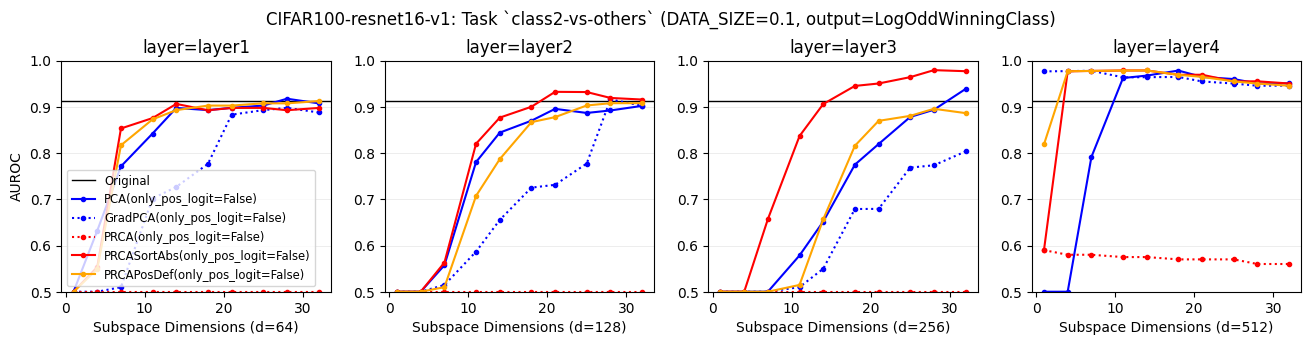

In [25]:
def viz(
    df, 
    arr_basis_names, 
    dict_ls_color_mapping
):

    def ls_color_mapping(basis_name, pos_logit_only):
        return dict_ls_color_mapping.get((basis_name, pos_logit_only), (None, None))

    arr_layers = df.layer.unique()
    ncols = len(arr_layers)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(
        f"CIFAR100-resnet16-v1: Task `{SELECTED_GROUP}-vs-others` (DATA_SIZE={DATA_SIZE}, output={OUTPUT_QUANTITY})", 
        y=1.05
    )

    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.ylim([0.5, 1])
        plt.title(f"layer={layer}")
        d = LAYER_DIM_MAPPING[layer]
        
        for bix, (basis_name, pos_logit_only) in enumerate(arr_basis_names):
            _df = df[
            (df.basis_name == basis_name) \
                & (df.positive_logits == pos_logit_only) \
                & (df.layer==layer)
            ]
            assert _df.shape[0] > 0
            if bix == 0:
                plt.axhline(ref_performance, label="Original", color="k", lw=1, ls="-")
                for v in [0.5, 0.6, 0.7, 0.8, 0.9]:
                    plt.axhline(v, lw=0.5, ls="-", alpha=0.1, color="k")
            ls, color = ls_color_mapping(basis_name, pos_logit_only=pos_logit_only)
            plt.plot(
                _df.k,
                _df.val_auroc,
                marker=".",
                label=f"{basis_name}(only_pos_logit={pos_logit_only})",
                ls=ls,
                color=color
            )

        if lix == 0:
            plt.ylabel("AUROC")
            plt.legend(fontsize="small")
        plt.xlabel(f"Subspace Dimensions (d={d})")
        
viz(
    pd.concat([df_stats_all_samples, df_stats_pos_logit_samples]), 
    arr_basis_names = [
        ("PCA", False),
        ("GradPCA", False),
        ("PRCA", False),
        ("PRCASortAbs", False),
        ("PRCAPosDef", False),
        # ("PRCAPosDefNormWithFrobenious", False),
        # ("PRCAPosDefNormWithLargestEigval", False),
        
        # ("PRCAPosDef", True),
        # ("PRCAPosDefNormWithFrobenious", True),
        # ("PRCAPosDefNormWithLargestEigval", True),
    ],
     dict_ls_color_mapping={
         ("PCA", False):         ("-", "blue"),
         ("GradPCA", False):     (":", "blue"),
          
         ("PRCASortAbs", False): ("-", "red"),
         ("PRCA", False):        (":", "red"),
         
         ("PRCAPosDef", False): ("-", "orange"),
         
         # ("PRCAPosDef", False): ("-", "black"),
         # ("PRCAPosDefNormWithFrobenious", False): ("-", "red"),

         # ("PRCAPosDef", True): (":", "black"),
         # ("PRCAPosDefNormWithFrobenious", True): (":", "red"),
         
         # ("PRCAPosDefNormWithLargestEigval", False): ("-", "blue"),
         # ("PRCAPosDefNormWithLargestEigval", True): (":", "blue"),
    }
)

In [26]:
# viz(
#     df_stats_all_samples, 
#     arr_basis_names = [
#         ("PRCAPosDefNoNormalization", False),
#         ("PRCAPosDef", False)
#     ],
#      dict_ls_color_mapping={
#          ("PRCAPosDefNoNormalization", False): (":", "blue"),
#          ("PRCAPosDef", False): ("-", "blue"),
#     }
# )

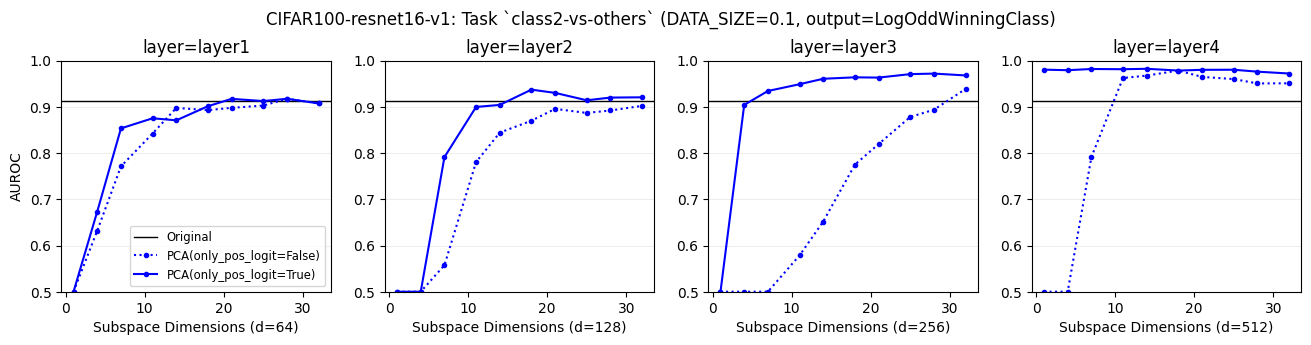

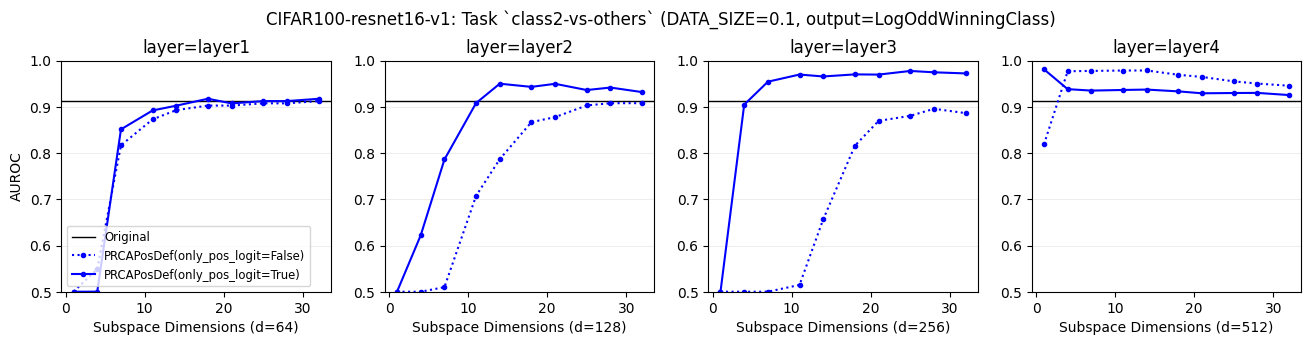

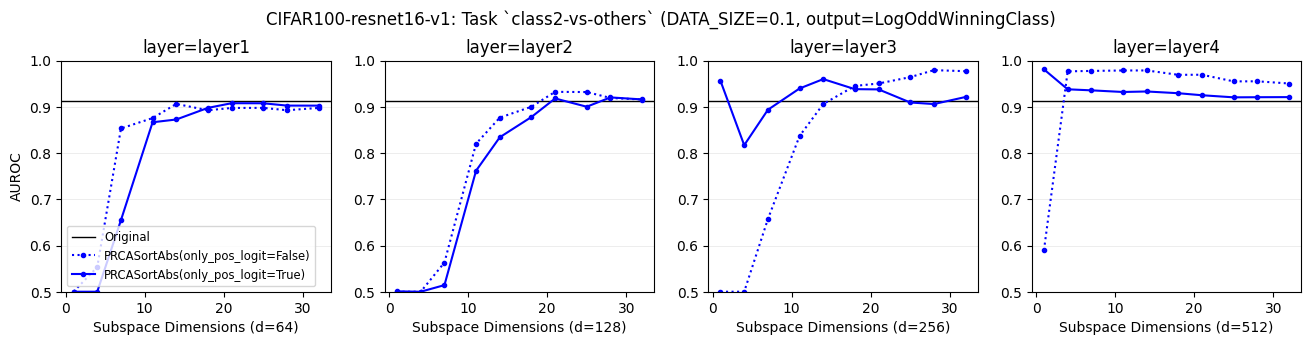

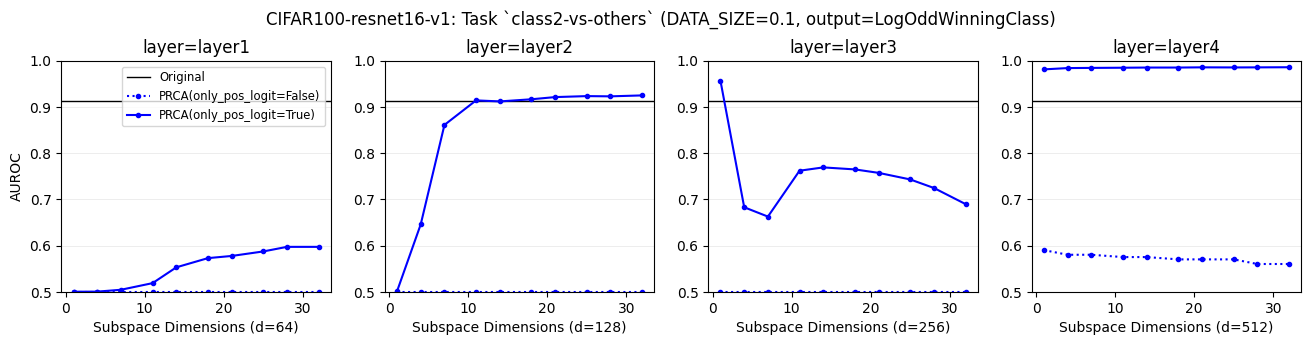

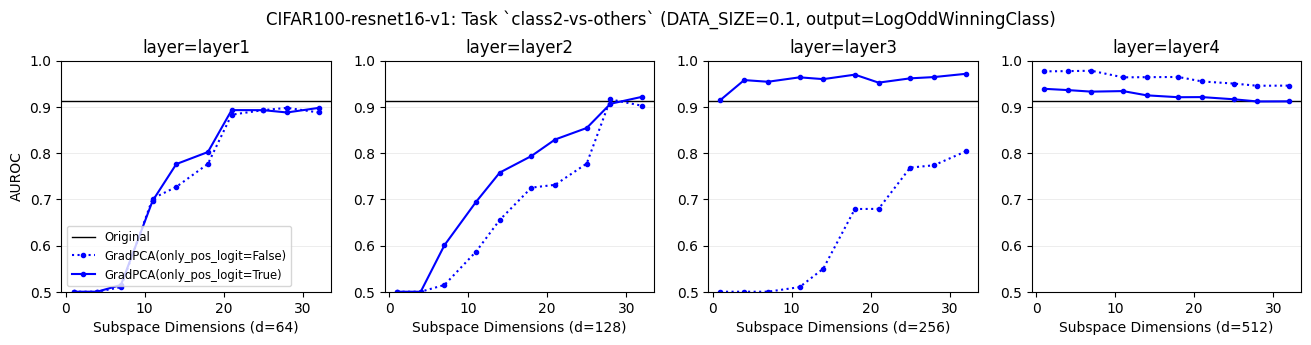

In [27]:
for basis_name in [
    "PCA", 

    "PRCAPosDef",
    
    "PRCASortAbs",
    "PRCA", 
    "GradPCA", 
]:
    viz(
        pd.concat([df_stats_all_samples, df_stats_pos_logit_samples]), 
        arr_basis_names = [
            (basis_name, False),
            (basis_name, True),
        ],
         dict_ls_color_mapping={
            (basis_name, False):  (":", "blue"),
            (basis_name, True):   ("-", "blue"),
        }
    )
    plt.show()

In [ ]:
viz(
    df_stats_pos_logit_samples, 
    arr_basis_names = [
        ("PCA", True),
        ("GradPCA", True),
        ("PRCA", True),
        ("PRCASortAbs", True),
        ("PRCAPosDef", True)
    ],
     dict_ls_color_mapping={
         ("PCA", True):         ("-", "blue"),     
         ("GradPCA", True):     (":", "blue"),          
         ("PRCA", True):        (":", "red"),
         ("PRCASortAbs", True): ("-", "red"),
         ("PRCAPosDef", True):  ("-", "orange"),
    }
)

In [ ]:
print(f"Finished at {datetime.now()}")